In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import random

random.seed(42)
%matplotlib inline


In [2]:

DATA_DIR = r"casting_data/train"  

N_SAMPLES = 25   # images per class

ok_paths  = sorted(glob.glob(os.path.join(DATA_DIR, "ok_front", "*.jpeg")) +
                    glob.glob(os.path.join(DATA_DIR, "ok_front", "*.jpg")) +
                    glob.glob(os.path.join(DATA_DIR, "ok_front", "*.png")))
def_paths = sorted(glob.glob(os.path.join(DATA_DIR, "def_front", "*.jpeg")) +
                    glob.glob(os.path.join(DATA_DIR, "def_front", "*.jpg")) +
                    glob.glob(os.path.join(DATA_DIR, "def_front", "*.png")))

random.shuffle(ok_paths)
random.shuffle(def_paths)
ok_paths  = ok_paths[:N_SAMPLES]
def_paths = def_paths[:N_SAMPLES]

print(f"Loaded {len(ok_paths)} ok_front images and {len(def_paths)} def_front images")
assert len(ok_paths) > 0 and len(def_paths) > 0, "No images found - check DATA_DIR path!"


Loaded 25 ok_front images and 25 def_front images


In [3]:
def extract_shape_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    eq = cv2.equalizeHist(gray)
    blur = cv2.medianBlur(eq, 5)

    # Robust outer-boundary detection: Hough circle instead of global threshold
    circles = cv2.HoughCircles(
        blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=200,
        param1=80, param2=40,
        minRadius=int(0.30 * min(h, w)), maxRadius=int(0.55 * min(h, w))
    )
    if circles is None:
        return None
    cx, cy, r0 = np.round(circles[0][0]).astype(int)

    # Shape descriptors of the detected outer boundary
    theta = np.linspace(0, 2 * np.pi, 90)
    circle_pts = np.array(
        [[int(cx + r0 * np.cos(t)), int(cy + r0 * np.sin(t))] for t in theta]
    ).reshape(-1, 1, 2)
    area = cv2.contourArea(circle_pts)
    perimeter = cv2.arcLength(circle_pts, True)
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    hull = cv2.convexHull(circle_pts)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    # Interior texture descriptors (exclude bright outer rim + center bore)
    mask = np.zeros((h, w), np.uint8)
    cv2.circle(mask, (cx, cy), int(r0 * 0.75), 255, -1)
    cv2.circle(mask, (cx, cy), int(r0 * 0.12), 0, -1)

    texture_std = float(gray[mask == 255].std())
    edges = cv2.Canny(blur, 50, 150)
    edge_density = float((edges[mask == 255] > 0).mean())

    return {
        "img": img, "gray": gray, "circle": (cx, cy, r0), "contour": circle_pts,
        "area": area, "perimeter": perimeter,
        "circularity": circularity, "solidity": solidity,
        "texture_std": texture_std, "edge_density": edge_density,
    }


In [4]:
results = []

for p in ok_paths:
    f = extract_shape_features(p)
    if f:
        results.append({"path": p, "label": "ok", **f})

for p in def_paths:
    f = extract_shape_features(p)
    if f:
        results.append({"path": p, "label": "defective", **f})

skipped = (len(ok_paths) + len(def_paths)) - len(results)
print(f"Extracted features for {len(results)} images ({skipped} skipped - no circle found)")


Extracted features for 50 images (0 skipped - no circle found)


In [5]:
ok_rows = [r for r in results if r["label"] == "ok"]

def stats(key):
    vals = [r[key] for r in ok_rows]
    return float(np.mean(vals)), float(np.std(vals))

circ_mean, circ_std = stats("circularity")
sol_mean, sol_std = stats("solidity")
tex_mean, tex_std = stats("texture_std")
edge_mean, edge_std = stats("edge_density")

print(f"OK circularity   mean={circ_mean:.3f} std={circ_std:.3f}")
print(f"OK solidity      mean={sol_mean:.3f} std={sol_std:.3f}")
print(f"OK texture_std   mean={tex_mean:.2f} std={tex_std:.2f}")
print(f"OK edge_density  mean={edge_mean:.4f} std={edge_std:.4f}")

MARGIN = 1.5

def classify(r):
    if r["circularity"] < circ_mean - MARGIN * circ_std:
        return "defective"
    if r["solidity"] < sol_mean - MARGIN * sol_std:
        return "defective"
    if abs(r["texture_std"] - tex_mean) > MARGIN * max(tex_std, 1e-6):
        return "defective"
    if abs(r["edge_density"] - edge_mean) > MARGIN * max(edge_std, 1e-6):
        return "defective"
    return "ok"

for r in results:
    r["predicted"] = classify(r)


OK circularity   mean=0.997 std=0.001
OK solidity      mean=1.000 std=0.000
OK texture_std   mean=77.54 std=5.66
OK edge_density  mean=0.0886 std=0.0060


In [6]:
correct = sum(1 for r in results if r["predicted"] == r["label"])
accuracy = correct / len(results)
print(f"Accuracy on sampled set: {accuracy*100:.1f}%  ({correct}/{len(results)})")

tp = sum(1 for r in results if r["label"]=="defective" and r["predicted"]=="defective")
fn = sum(1 for r in results if r["label"]=="defective" and r["predicted"]=="ok")
tn = sum(1 for r in results if r["label"]=="ok" and r["predicted"]=="ok")
fp = sum(1 for r in results if r["label"]=="ok" and r["predicted"]=="defective")

print("\nConfusion matrix:")
print(f"                 predicted ok   predicted defective")
print(f"actual ok            {tn:5d}            {fp:5d}")
print(f"actual defective     {fn:5d}            {tp:5d}")


Accuracy on sampled set: 42.0%  (21/50)

Confusion matrix:
                 predicted ok   predicted defective
actual ok               13               12
actual defective        17                8


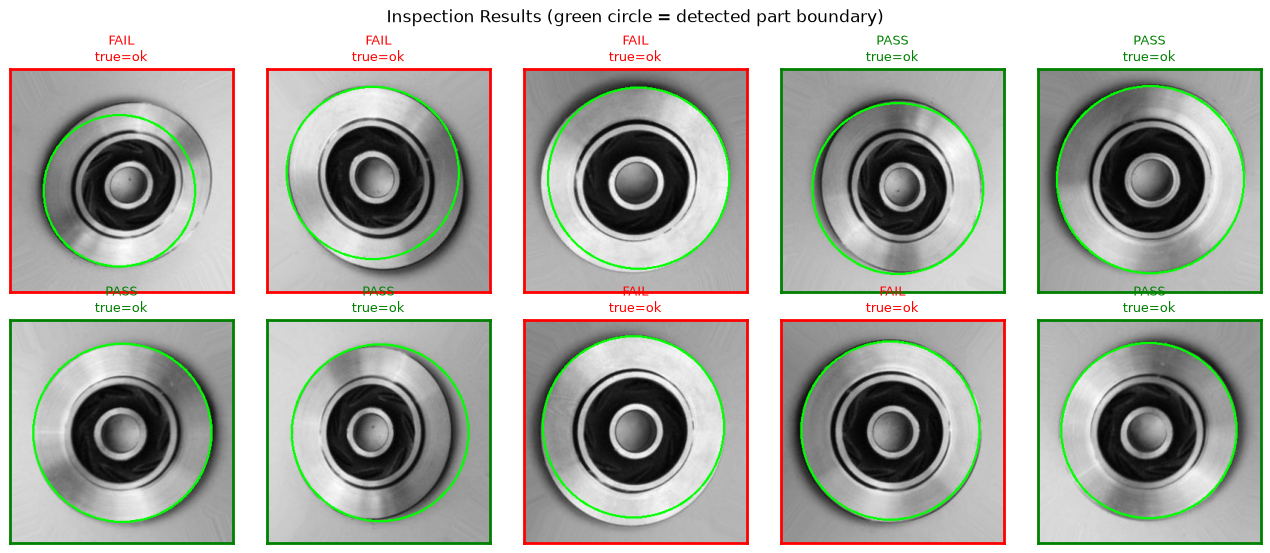

In [7]:
def show_grid(items, cols=5, title=""):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.6, rows*2.8))
    axes = np.array(axes).reshape(-1)

    for ax, r in zip(axes, items):
        vis = r["img"].copy()
        cx, cy, r0 = r["circle"]
        cv2.circle(vis, (cx, cy), r0, (0, 255, 0), 2)
        vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
        ax.imshow(vis_rgb)
        correct = r["predicted"] == r["label"]
        tag = "PASS" if r["predicted"] == "ok" else "FAIL"
        color = "green" if correct else "red"
        ax.set_title(f"{tag}\ntrue={r['label']}", fontsize=9, color=color)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
        ax.set_xticks([]); ax.set_yticks([])

    for ax in axes[len(items):]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

sample_to_show = results[:10]
show_grid(sample_to_show, cols=5, title="Inspection Results (green circle = detected part boundary)")


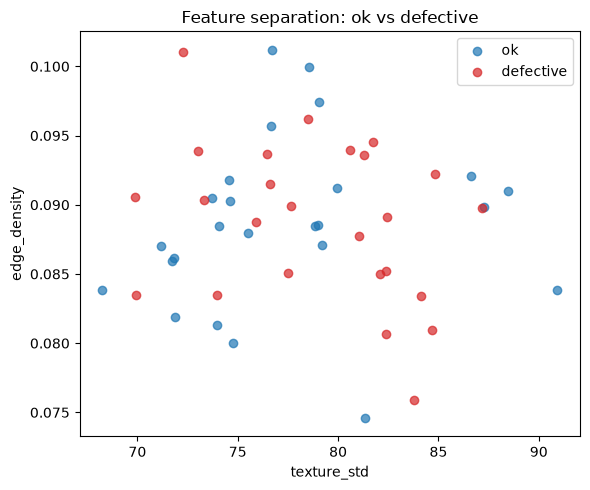

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
for label, color in [("ok", "tab:blue"), ("defective", "tab:red")]:
    xs = [r["texture_std"] for r in results if r["label"] == label]
    ys = [r["edge_density"] for r in results if r["label"] == label]
    ax.scatter(xs, ys, c=color, label=label, alpha=0.7)
ax.set_xlabel("texture_std")
ax.set_ylabel("edge_density")
ax.set_title("Feature separation: ok vs defective")
ax.legend()
plt.tight_layout()
plt.show()
